In [22]:
from pathlib import Path
import json
import sys

from IPython.display import Image, Markdown, display
from astropy.table import Table

ROOT = Path.cwd().resolve()
DATA_ROOT = ROOT / "data" / "suzaku"
OUTPUT_ROOT = ROOT / "outputs"

ACQUIRE_MISSING = False  # True downloads EHK plus all standard 3x3/5x5 GTI products for one XIS.
RUN_ANALYSIS = True     # Inspect readiness first; set True for field integration.
FORCE = False            # True recomputes outputs even when provenance matches.
OBSERVATION_LIMIT = None # Set to 1 or 2 for a smoke run; None is the full cohort.
MAX_SAMPLES = None       # Optional per-observation calculation limit for smoke tests.

CADENCE_S = 60.0
Q_PER_M = 0.0
INITIAL_INTERVALS = 32
MAX_INTERVALS = 256
RELATIVE_TOLERANCE = 0.01

if not (ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook from the ALP project directory.")
print(f"Python: {sys.executable}")
print(f"Project: {ROOT}")

Python: c:\Users\phial\Documents\Python\darkmatter\ALP\.venv\Scripts\python.exe
Project: C:\Users\phial\Documents\Python\darkmatter\ALP


# Yamamoto Four-Field Geometry Cohort

Notebook interface for the provenance-locked Suzaku geometry cohort. Production calculations remain in `darkness_alp`. This stage does not perform spectral, background, limit, or DarkNESS mission modeling.

In [23]:
import forms
import darkness_alp
from darknessalp.yamamoto.archive import (
    DEFAULT_COHORT,
    inspect_cohort,
    prepare_cohort,
    validate_manifest,
)
from darknessalp.yamamoto.cohort import validate_cohort

expected_environment = ROOT / ".venv"
active_environment = Path(sys.executable).resolve().parents[1]
if active_environment != expected_environment:
    raise RuntimeError(
        "Select the 'DarkNESS ALP (.venv)' kernel before running this notebook. "
        f"Active interpreter: {sys.executable}"
    )

manifest = validate_manifest()
print(f"darkness_alp {darkness_alp.__version__}")
print(f"FORMS {forms.__version__}")
display(manifest)

darkness_alp 0.2.0
FORMS 20260708.2057


{'valid': True,
 'primary_count': 23,
 'supplemental_count': 1,
 'field_counts': {'Lockman Hole': 9, 'MBM16': 6, 'SEP': 4, 'NEP': 4},
 'paper_lockman_count_note': 'Yamamoto et al. report 11 Lockman observations; this provenance-locked primary cohort contains the nine annual thesis observations. 104002020 is supplemental, and no duplicated ID is used.'}

In [24]:
statuses = (
    prepare_cohort(data_root=DATA_ROOT)
    if ACQUIRE_MISSING
    else inspect_cohort(data_root=DATA_ROOT)
)
status_rows = [status.to_dict() for status in statuses]
display(Table(rows=status_rows))

primary_ready = sum(status.primary and status.status == "ready" for status in statuses)
display(Markdown(
    f"**Primary products ready: {primary_ready}/23.** "
    "Only rows marked `ready` can enter the geometry calculation."
))

obsid,field,primary,status,xis,ehk_path,event_path,observed_ra_deg,observed_dec_deg,target_separation_deg,rejection_reason
str9,str12,bool,str5,int64,str84,str106,float64,float64,float64,str1
101002010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\101002010\ae101002010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\101002010\xis0\ae101002010xi0_0_3x3n000a_cl.evt,162.9366,57.2557,0.000369878156552887,
102018010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\102018010\ae102018010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\102018010\xis0\ae102018010xi0_0_3x3n066a_cl.evt,162.9257,57.2581,0.00019059815438025122,
103009010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\103009010\ae103009010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\103009010\xis0\ae103009010xi0_0_3x3n066a_cl.evt,162.9369,57.2546,0.00040364084857316115,
104002010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\104002010\ae104002010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\104002010\xis0\ae104002010xi0_0_3x3n066a_cl.evt,162.9377,57.2549,0.00019060962732714287,
105003010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\105003010\ae105003010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\105003010\xis0\ae105003010xi0_0_3x3n066l_cl.evt,162.9382,57.2507,0.0003189138861350545,
106001010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\106001010\ae106001010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\106001010\xis0\ae106001010xi0_0_3x3n066j_cl.evt,162.9265,57.2528,0.000336380315746229,
107001010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\107001010\ae107001010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\107001010\xis0\ae107001010xi0_0_3x3n066l_cl.evt,162.9197,57.2548,0.00025755111910489187,
108001010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\108001010\ae108001010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\108001010\xis0\ae108001010xi0_0_3x3n066h_cl.evt,162.9444,57.2754,0.0004547096165499538,
109014010,Lockman Hole,True,ready,0,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\109014010\ae109014010.ehk,C:\Users\phial\Documents\Python\darkmatter\ALP\data\suzaku\109014010\xis0\ae109014010xi0_0_3x3n066l_cl.evt,162.9402,57.278,0.00010810945668844369,


**Primary products ready: 23/23.** Only rows marked `ready` can enter the geometry calculation.

In [25]:
summary_path = OUTPUT_ROOT / "yamamoto_cohort" / "cohort_summary.json"
if RUN_ANALYSIS:
    summary = validate_cohort(
        data_root=DATA_ROOT,
        output_root=OUTPUT_ROOT,
        acquire=ACQUIRE_MISSING,
        force=FORCE,
        cadence_s=CADENCE_S,
        q_per_m=Q_PER_M,
        initial_intervals=INITIAL_INTERVALS,
        max_intervals=MAX_INTERVALS,
        relative_tolerance=RELATIVE_TOLERANCE,
        max_samples=MAX_SAMPLES,
        observation_limit=OBSERVATION_LIMIT,
    )
elif summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    print("Loaded the most recent cohort summary; RUN_ANALYSIS is False.")
else:
    summary = None
    print("Readiness inspection complete. No cohort calculation was requested.")

[2026-07-30 21:06:18.603] [FORMS] [WARNING] EOP data is 34 days old - consider updating (C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib\EOP-All-v1.1_2026-06-28.txt)
[2026-07-30 21:06:18.606] [FORMS] [INFO] IAU/EOP data directory: C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib
[2026-07-30 21:07:22.585] [FORMS] [WARNING] EOP data is 34 days old - consider updating (C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib\EOP-All-v1.1_2026-06-28.txt)
[2026-07-30 21:07:22.587] [FORMS] [INFO] IAU/EOP data directory: C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib
[2026-07-30 21:08:28.180] [FORMS] [WARNING] EOP data is 34 days old - consider updating (C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib\EOP-All-v1.1_2026-06-28.txt)
[2026-07-30 21:08:28.182] [FORMS] [INFO] IAU/EOP data directory: C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib
[2026-07-30 2

## Cohort result: PASS
- Primary products ready: **23/23**  
- Primary observations accepted: **23/23**  
- Published-bin agreement: **True**

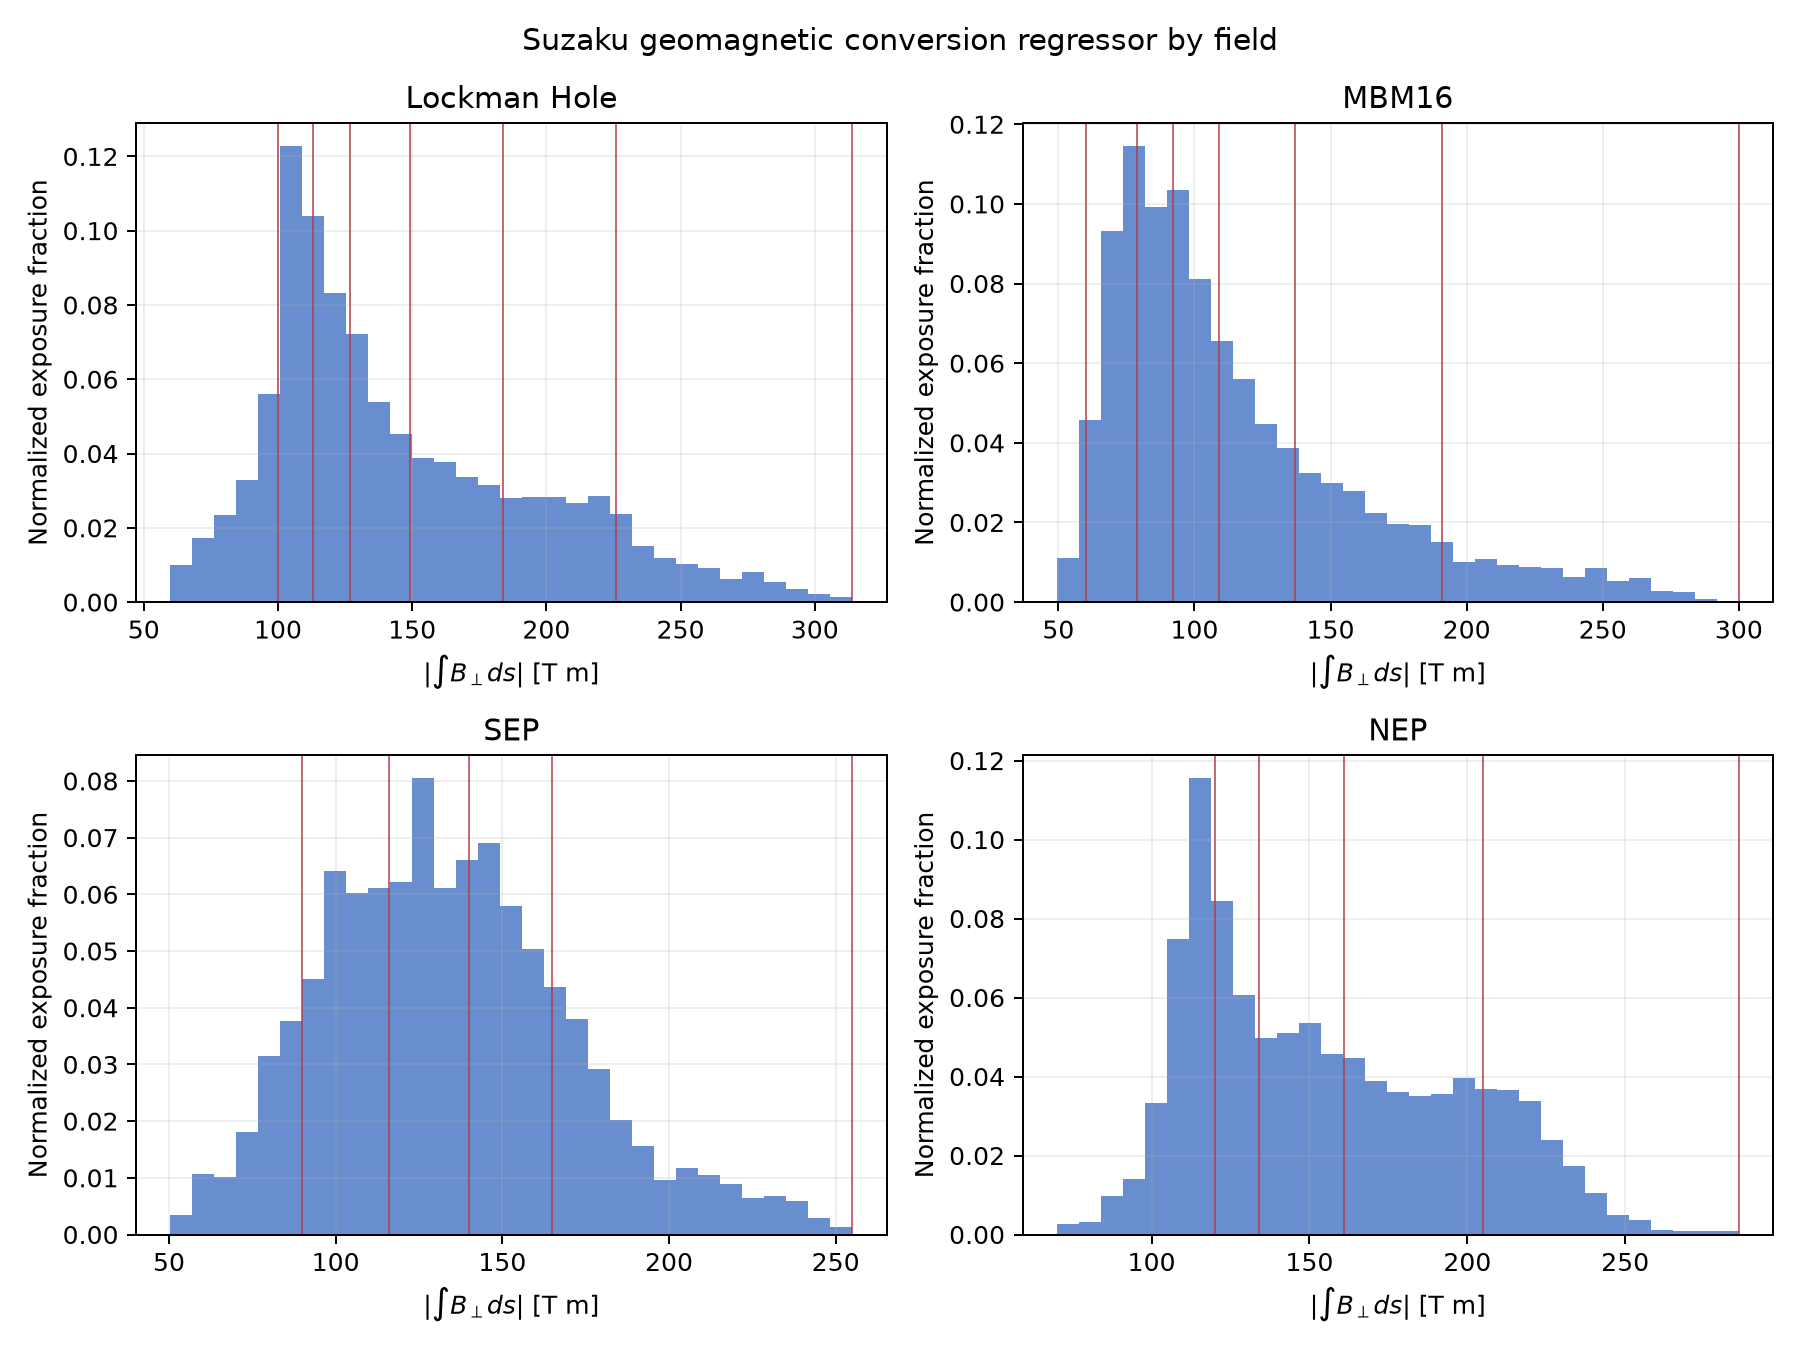

obsid,field,primary,product_status,analysis_status,cache_reused,xis,sample_count,gti_exposure_s,valid_integral_fraction,converged_fraction,b2_p05_t2m2,b2_median_t2m2,b2_p95_t2m2,acceptance_pass,reason
int64,str12,str5,str5,str8,str5,int64,int64,float64,float64,float64,float64,float64,float64,str4,int64
101002010,Lockman Hole,True,ready,complete,True,0,999,59001.074851453304,1.0,1.0,2501.9764751370626,16405.834062389185,49296.16535727182,True,--
102018010,Lockman Hole,True,ready,complete,False,0,1158,68881.84667441249,1.0,1.0,9910.501247083248,13152.240511586984,55678.460927921726,True,--
103009010,Lockman Hole,True,ready,complete,False,0,1233,73309.40499258041,1.0,1.0,1002.4460918205978,29371.722271943625,58311.25499353006,True,--
104002010,Lockman Hole,True,ready,complete,False,0,1213,71402.24259620905,1.0,1.0,1367.6036967590228,19690.874832730136,74318.61936349348,True,--
105003010,Lockman Hole,True,ready,complete,False,0,933,55276.46773207188,1.0,1.0,7943.479065671468,13422.058940250516,66955.11238487749,True,--
106001010,Lockman Hole,True,ready,complete,False,0,611,30690.479556322098,1.0,1.0,952.7938039575554,26577.906846399415,57834.160854759895,True,--
107001010,Lockman Hole,True,ready,complete,False,0,608,35933.704948067665,1.0,1.0,8586.641928164505,15420.676300681655,30457.638871562922,True,--
108001010,Lockman Hole,True,ready,complete,False,0,1,8.376464784145355,1.0,1.0,9066.141449413028,9066.141449413028,9066.141449413028,True,--
109014010,Lockman Hole,True,ready,complete,False,0,636,37057.079874396324,1.0,1.0,3708.7261262408074,16768.981038188067,75382.78770190259,True,--


field,bin_index,lower_tm,upper_tm,published_mean_t2m2,calculated_mean_t2m2,relative_difference,within_15_percent,sample_count,exposure_s,normalized_exposure_fraction
str12,int64,int64,int64,int64,float64,float64,str4,int64,float64,float64
Lockman Hole,1,100,113,11470,11360.247754224232,0.009568635202769637,True,979,58531.68852201104,0.18597231247987436
Lockman Hole,2,113,127,14256,14322.30900081948,0.004651304771287842,True,786,46838.63767448068,0.14882006621856556
Lockman Hole,3,127,149,18879,18756.90647693272,0.0064671604993527376,True,785,46726.947639495134,0.1484651942746371
Lockman Hole,4,149,184,27423,27458.113854615043,0.0012804527081297903,True,806,47749.069395810366,0.1517127743711254
Lockman Hole,5,184,226,42230,42235.7199265322,0.00013544699342168742,True,783,45918.81606647372,0.14589752364667852
Lockman Hole,6,226,314,64060,65128.497903589865,0.016679642578674134,True,515,27706.222371160984,0.08803078083948983
MBM16,1,60,79,5128,5077.69268312816,0.009810319202776942,True,874,51892.67491680384,0.20660135905161467
MBM16,2,79,92,7309,7301.378621256586,0.0010427389168715863,True,696,41384.88756483793,0.16476649216487152
MBM16,3,92,109,9934,9952.250685143883,0.001837193994753669,True,768,45941.533657968044,0.1829079596661559


In [26]:
if summary is not None:
    acceptance = summary["acceptance"]
    display(Markdown(
        "## Cohort result: " + ("PASS" if acceptance["pass"] else "INCOMPLETE / DISCREPANCY") + "\n"
        f"- Primary products ready: **{summary['primary_ready_count']}/23**  \n"
        f"- Primary observations accepted: **{summary['primary_accepted_count']}/23**  \n"
        f"- Published-bin agreement: **{acceptance['all_published_bins_within_15_percent']}**"
    ))
    cohort_dir = OUTPUT_ROOT / "yamamoto_cohort"
    figure = cohort_dir / summary["artifacts"]["figure"]
    if figure.exists():
        display(Image(filename=str(figure)))
    display(Table.read(cohort_dir / summary["artifacts"]["observations"]))
    display(Table.read(cohort_dir / summary["artifacts"]["bins"]))